In [1]:
import pandas as pd
from fredapi import Fred
import requests
import time
import plotly.express as px
import os

In [2]:
# Configuration
# Make sure that these API keys are defined as variables in the environment this code is running in
FRED_API_KEY = os.getenv("FRED_API_KEY")
HUD_API_TOKEN = os.getenv("HUD_API_TOKEN")
fred = Fred(api_key=FRED_API_KEY)

In [3]:
BASE_URL = "https://www.huduser.gov/hudapi/public/fmr"

headers = {
    "Authorization": f"Bearer {HUD_API_TOKEN}",
    "Content-Type": "application/json"
}

def build_national_mapping():
    states_resp = requests.get(f"{BASE_URL}/listStates", headers=headers)
    if states_resp.status_code != 200:
        return f"Error: {states_resp.status_code}"
    
    states = states_resp.json()
    national_map = {}

    for state in states:
        # 2026 Fix: HUD uses 'state_code' or 'id' for the FIPS ID
        state_id = state.get('state_code') or state.get('state_id') or state.get('id')
        state_name = state.get('state_name')
        
        if not state_id:
            print(f"Skipping state with missing ID. Keys available: {list(state.keys())}")
            continue
            
        county_url = f"{BASE_URL}/listCounties/{state_id}"
        c_resp = requests.get(county_url, headers=headers)
        
        if c_resp.status_code == 200:
            counties = c_resp.json()
            # We store the entire county object list for now
            national_map[state_name] = counties
            print(f"Mapped {state_name} ({len(counties)} counties)")
        
        time.sleep(0.1) 
        
    return national_map

# Run the mapping
national_mapping = build_national_mapping()
idaho_data = national_mapping.get('Idaho')

Mapped Alabama (67 counties)
Mapped Alaska (30 counties)
Mapped American Samoa (1 counties)
Mapped Arizona (15 counties)
Mapped Arkansas (75 counties)
Mapped California (58 counties)
Mapped Colorado (64 counties)
Mapped Connecticut (169 counties)
Mapped Delaware (3 counties)
Mapped District of Columbia (1 counties)
Mapped Florida (67 counties)
Mapped Georgia (159 counties)
Mapped Guam (1 counties)
Mapped Hawaii (5 counties)
Mapped Idaho (44 counties)
Mapped Illinois (102 counties)
Mapped Indiana (92 counties)
Mapped Iowa (99 counties)
Mapped Kansas (105 counties)
Mapped Kentucky (120 counties)
Mapped Louisiana (64 counties)
Mapped Maine (530 counties)
Mapped Maryland (24 counties)
Mapped Massachusetts (351 counties)
Mapped Michigan (83 counties)
Mapped Minnesota (87 counties)
Mapped Mississippi (82 counties)
Mapped Missouri (116 counties)
Mapped Montana (56 counties)
Mapped Nebraska (93 counties)
Mapped Nevada (17 counties)
Mapped New Hampshire (259 counties)
Mapped New Jersey (21 coun

In [4]:
print(national_mapping)

{'Alabama': [{'state_code': 'AL', 'fips_code': '0100199999', 'county_name': 'Autauga County', 'town_name': '', 'category': 'County'}, {'state_code': 'AL', 'fips_code': '0100399999', 'county_name': 'Baldwin County', 'town_name': '', 'category': 'County'}, {'state_code': 'AL', 'fips_code': '0100599999', 'county_name': 'Barbour County', 'town_name': '', 'category': 'County'}, {'state_code': 'AL', 'fips_code': '0100799999', 'county_name': 'Bibb County', 'town_name': '', 'category': 'County'}, {'state_code': 'AL', 'fips_code': '0100999999', 'county_name': 'Blount County', 'town_name': '', 'category': 'County'}, {'state_code': 'AL', 'fips_code': '0101199999', 'county_name': 'Bullock County', 'town_name': '', 'category': 'County'}, {'state_code': 'AL', 'fips_code': '0101399999', 'county_name': 'Butler County', 'town_name': '', 'category': 'County'}, {'state_code': 'AL', 'fips_code': '0101599999', 'county_name': 'Calhoun County', 'town_name': '', 'category': 'County'}, {'state_code': 'AL', 'fi

In [5]:
print(idaho_data)

[{'state_code': 'ID', 'fips_code': '1600199999', 'county_name': 'Ada County', 'town_name': '', 'category': 'County'}, {'state_code': 'ID', 'fips_code': '1600399999', 'county_name': 'Adams County', 'town_name': '', 'category': 'County'}, {'state_code': 'ID', 'fips_code': '1600599999', 'county_name': 'Bannock County', 'town_name': '', 'category': 'County'}, {'state_code': 'ID', 'fips_code': '1600799999', 'county_name': 'Bear Lake County', 'town_name': '', 'category': 'County'}, {'state_code': 'ID', 'fips_code': '1600999999', 'county_name': 'Benewah County', 'town_name': '', 'category': 'County'}, {'state_code': 'ID', 'fips_code': '1601199999', 'county_name': 'Bingham County', 'town_name': '', 'category': 'County'}, {'state_code': 'ID', 'fips_code': '1601399999', 'county_name': 'Blaine County', 'town_name': '', 'category': 'County'}, {'state_code': 'ID', 'fips_code': '1601599999', 'county_name': 'Boise County', 'town_name': '', 'category': 'County'}, {'state_code': 'ID', 'fips_code': '160

In [6]:
def build_county_metrics(national_mapping, hud_token, fred_api_key):
    results = []
    
    # Base configuration for FRED Search
    search_url = "https://api.stlouisfed.org/fred/series/search"
    obs_url = "https://api.stlouisfed.org/fred/series/observations"
    
    for state_name, counties in national_mapping.items():
        print(f"Processing {state_name}...")
        
        for county in counties:
            
            full_fips = county['fips_code']
            short_fips = full_fips[:5].zfill(5)
            state_code = county.get('state_code', '') # Extract 'AL', 'CT', etc.
            county_name = county['county_name']
            
            # --- 1. Get HUD Rent ---
            rent = None
            hud_url = f"https://www.huduser.gov/hudapi/public/fmr/data/{full_fips}"
            h_resp = requests.get(hud_url, headers={"Authorization": f"Bearer {hud_token}"}, params={"year": "2026"})
            
            if h_resp.status_code == 200:
                try:
                    data = h_resp.json().get('data', {})
                    if isinstance(data, list) and len(data) > 0: data = data[0]
                    rent_str = data.get('basicdata', {}).get('Two-Bedroom', '0')
                    rent = float(str(rent_str).replace('$', '').replace(',', ''))
                except: pass

            # --- 2. Get FRED Price (Search + County + State Fallback) ---
            price = None
            series_id = None
            
            # Step A: Try a quick search to find the "Realtor" Series ID for this county
            search_params = {
                "search_text": f"Median Listing Price {county_name} {state_code}",
                "api_key": fred_api_key.strip(),
                "file_type": "json"
            }
            try:
                s_resp = requests.get(search_url, params=search_params)
                if s_resp.status_code == 200:
                    seriess = s_resp.json().get('seriess', [])
                    if seriess: series_id = seriess[0]['id']
            except: pass

            # Step B: If search failed, fallback to standard FIPS guess
            if not series_id:
                series_id = f"MEDLISPRI{short_fips}"

            # Step C: Pull the observation
            f_params = {
                "series_id": series_id,
                "api_key": fred_api_key.strip(),
                "file_type": "json",
                "sort_order": "desc",
                "limit": 1
            }
            
            f_resp = requests.get(obs_url, params=f_params)
            if f_resp.status_code == 200:
                obs = f_resp.json().get('observations', [])
                if obs and obs[0]['value'] != '.':
                    price = float(obs[0]['value'])
            
            # Step D: Final Fallback - If County price is still None or suspicously low, use State Median
            if price is None or price < 10000:
                state_f_resp = requests.get(obs_url, params={**f_params, "series_id": f"MEDLISPRI{state_code}"})
                if state_f_resp.status_code == 200:
                    s_obs = state_f_resp.json().get('observations', [])
                    if s_obs and s_obs[0]['value'] != '.':
                        price = float(s_obs[0]['value'])

            # --- 3. Store Results ---
            county_data = {
                "fips": short_fips,
                "state": state_name,
                "county": county_name,
                "rent": rent,
                "median_price": price,
                "data_level": "county" if series_id and price else "state_fallback"
            }
            results.append(county_data)
            print(county_data)
            
            time.sleep(0.15) # slow for search reliability
            
    return results

metrics_list = build_county_metrics(national_mapping, HUD_API_TOKEN, FRED_API_KEY)

Processing Alabama...
{'fips': '01001', 'state': 'Alabama', 'county': 'Autauga County', 'rent': None, 'median_price': 322848.0, 'data_level': 'county'}
{'fips': '01003', 'state': 'Alabama', 'county': 'Baldwin County', 'rent': 1345.0, 'median_price': 499500.0, 'data_level': 'county'}
{'fips': '01005', 'state': 'Alabama', 'county': 'Barbour County', 'rent': 776.0, 'median_price': 329144.0, 'data_level': 'county'}
{'fips': '01007', 'state': 'Alabama', 'county': 'Bibb County', 'rent': None, 'median_price': 329144.0, 'data_level': 'county'}
{'fips': '01009', 'state': 'Alabama', 'county': 'Blount County', 'rent': None, 'median_price': 299225.0, 'data_level': 'county'}
{'fips': '01011', 'state': 'Alabama', 'county': 'Bullock County', 'rent': None, 'median_price': 329144.0, 'data_level': 'county'}
{'fips': '01013', 'state': 'Alabama', 'county': 'Butler County', 'rent': None, 'median_price': 329144.0, 'data_level': 'county'}
{'fips': '01015', 'state': 'Alabama', 'county': 'Calhoun County', 'ren

In [7]:
print(metrics_list[0])

{'fips': '01001', 'state': 'Alabama', 'county': 'Autauga County', 'rent': None, 'median_price': 322848.0, 'data_level': 'county'}


In [8]:
df = pd.DataFrame(metrics_list)
df.to_csv('county_housing_buy_vs_rent.csv', index=False)

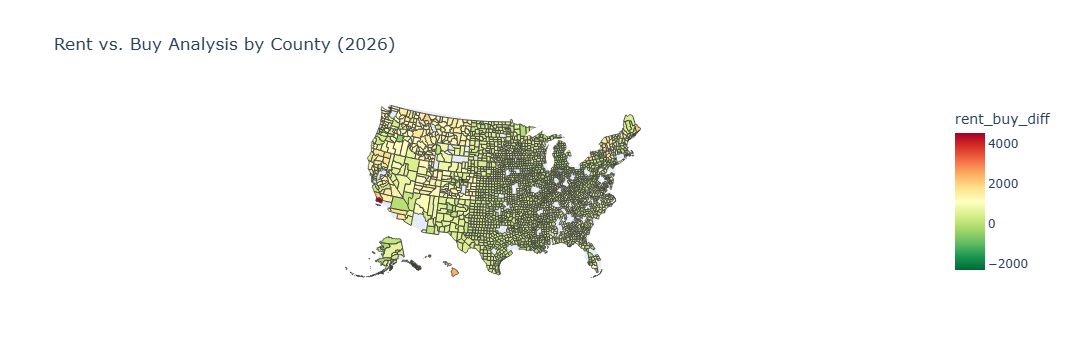

In [10]:
# Calculate the "5% Rule" metric for the map
# (Price * 0.05 / 12) - Rent 
# Positive values = Renting is better | Negative = Buying is better
df['rent_buy_diff'] = (df['median_price'] * 0.05 / 12) - df['rent']

fig = px.choropleth(
    df,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations='fips',
    color='rent_buy_diff',
    color_continuous_scale="RdYlGn_r", # Red = Buying is expensive, Green = Buying is cheap
    scope="usa",
    hover_data=['county', 'state', 'rent', 'median_price'],
    title="Rent vs. Buy Analysis by County (2026)"
)

fig.show()